##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [1]:
# Import libraries
import keras_cv
import keras_core as keras
import numpy as np


import keras_cv
import keras_core as keras
import tensorflow as tf

import tempfile
import matplotlib.pyplot as plt
from urllib.request import urlopen, Request
from PIL import Image, ImageOps
from io import BytesIO

2026-03-05 21:10:19.914520: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/anaconda3/envs/cv_lab/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using TensorFlow backend


In [ ]:
# load YOLOV8Detector
detector = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

In [3]:
image_urls = [
    "https://cdn.datasetninja.com/previews/q/ext:jpeg/resize:fill:400:0:0/q:70/plain/supervisely-assets-public/images/original/P/k/2a/EcyylrxkOaBstutqezm1hHrb2jlzKDkNlQDFWqy5OwunPSIvcaILmapIVsYm55DWeWxto7rcTEZOgQtOzhg5bRLUFfBriGz6KfTQoe6zOxBX8iFdutDuJfCw10Xk.jpg",
    "https://cdn.datasetninja.com/previews/q/ext:jpeg/resize:fill:400:0:0/q:70/plain/supervisely-assets-public/images/original/t/z/Ag/ZfaFkR7vgecxi9KjO2uXs7xuGd0D7cODOk9C3Y3qFKTdl2rtiVQz1haRqKHJhKW8SU3dkiZ5cvWxMgwlC7EufQDd4mv0dDrLAxhxuR1andZspCZyKcXVU0C9nMMO.jpg",
    "https://cdn.datasetninja.com/previews/q/ext:jpeg/resize:fill:400:0:0/q:70/plain/supervisely-assets-public/images/original/0/r/Cq/nQRNZY5oBk2lPUrbaByqbDVZeJTOLGP8PadMWpyiWgnTRCs266I76DHA7XZNMdfHmlmBtXTYIsoLORlyThPodVlKeZHsQ26zJvPrjY3f8aMn7IeiSxkILRLIEf15.jpg",
    "https://cdn.datasetninja.com/previews/q/ext:jpeg/resize:fill:400:0:0/q:70/plain/supervisely-assets-public/images/original/y/v/N5/AVLSed1n18yYBYfK1PJgn8sRSiimm91UMnFjhNgJaPLFugKQ9Wm2sWvngxdurCGcl5GHnIXLvTFqhiBDjyaat2WFfWnTmHqrB7tZYWojLnSuXpNwdyVcgzYUyjpH.jpg",
    "https://cdn.datasetninja.com/previews/q/ext:jpeg/resize:fill:400:0:0/q:70/plain/supervisely-assets-public/images/original/T/l/3R/4HXMOmY1ErpNsizujXyWvAOa5Wlk0JpSMNywrgQqCpbmFvp2WeJHboxkxrJrdtZBuJv5M58U1JOisy0iI85CCMyVzmPR7U8pkGH83OH4s6FzbSabslvnwuCnlXw6.jpg",
]

In [4]:
def display_image(image):
  fig = plt.figure(figsize=(20, 15))
  plt.grid(False)
  plt.imshow(image)


def download_and_resize_image(url, new_width=256, new_height=256,
                              display=False):
  _, filename = tempfile.mkstemp(suffix=".jpg")

  headers = {"User-Agent": "Mozilla/5.0"}
  
  req = Request(url, headers=headers)
  
  response = urlopen(req)
  
  image_data = response.read()
  image_data = BytesIO(image_data)
  pil_image = Image.open(image_data)
  pil_image = ImageOps.fit(pil_image, (new_width, new_height), Image.LANCZOS)
  pil_image_rgb = pil_image.convert("RGB")
  pil_image_rgb.save(filename, format="JPEG", quality=90)
  print("Image downloaded to %s." % filename)
  if display:
    display_image(pil_image)
  return filename

In [ ]:
images = []
for url in image_urls:
    path = download_and_resize_image(url, 640, 640, display=False)  # temporarly 640
    img = np.array(Image.open(path).convert("RGB"))
    images.append(img)

images = np.stack(images, axis=0)  # (5, 640, 640, 3)

Image downloaded to /var/folders/15/qj8415356nd_bbq1jnqh98_m0000gn/T/tmp7r5yzm16.jpg.
Image downloaded to /var/folders/15/qj8415356nd_bbq1jnqh98_m0000gn/T/tmpxzqizn4k.jpg.
Image downloaded to /var/folders/15/qj8415356nd_bbq1jnqh98_m0000gn/T/tmppuoupwqc.jpg.
Image downloaded to /var/folders/15/qj8415356nd_bbq1jnqh98_m0000gn/T/tmpylwp3mpx.jpg.
Image downloaded to /var/folders/15/qj8415356nd_bbq1jnqh98_m0000gn/T/tmptl67zyqz.jpg.


In [6]:
inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )

images_resized = inference_resizing(images)

In [7]:
# 5) inference
preds = detector.predict(images_resized, verbose=0)

In [8]:
VOC_CLASS_MAPPING = {
0: "aeroplane",
1: "bicycle",
2: "bird",
3: "boat",
4: "bottle",
5: "bus",
6: "car",
7: "cat",
8: "chair",
9: "cow",
10: "diningtable",
11: "dog",
12: "horse",
13: "motorbike",
14: "person",
15: "pottedplant",
16: "sheep",
17: "sofa",
18: "train",
19: "tvmonitor"
}

In [ ]:
def run_one_image(url):
    #download_and_resize_image
    path = download_and_resize_image(url, 640, 640, display=False)
    img = np.array(Image.open(path).convert("RGB"))          # (640,640,3) uint8
    batch = img[None, ...]                                   # (1,640,640,3)

    batch_resized = inference_resizing(batch)

    pred = detector.predict(batch_resized, verbose=0)

    keras_cv.visualization.plot_bounding_box_gallery(
        batch_resized,
        value_range=(0, 255),
        y_pred=pred,
        bounding_box_format="xywh",
        class_mapping=VOC_CLASS_MAPPING,
        rows=1,
        cols=1,
        scale=4,        # scale img
        font_scale=0.8,
    )
    return pred

Image downloaded to /var/folders/15/qj8415356nd_bbq1jnqh98_m0000gn/T/tmpk9ycgmzt.jpg.


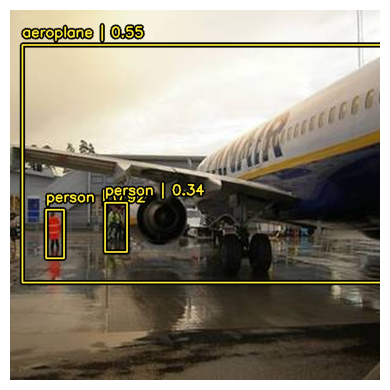

In [23]:
pred0 = run_one_image(image_urls[0])

    - Which objects were detected correctly
        All objects are detected corectly (aeroplane and person)
    - The confidence scores of the detections
        aeroplane — confidence 0.55
        aeroplane — confidence 0.55 & 0.92
    - Any missed or incorrectly labeled objects
        no

Image downloaded to /var/folders/15/qj8415356nd_bbq1jnqh98_m0000gn/T/tmp6prifr2j.jpg.


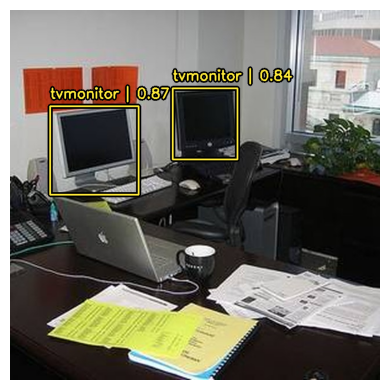

In [24]:
pred1 = run_one_image(image_urls[1])

    - Which objects were detected correctly
        the two tvmonitor
    - The confidence scores of the detections
        tvmonitor — confidence 0.87
        tvmonitor — confidence 0.84
    - Any missed or incorrectly labeled objects
        no

Image downloaded to /var/folders/15/qj8415356nd_bbq1jnqh98_m0000gn/T/tmp4axol5im.jpg.


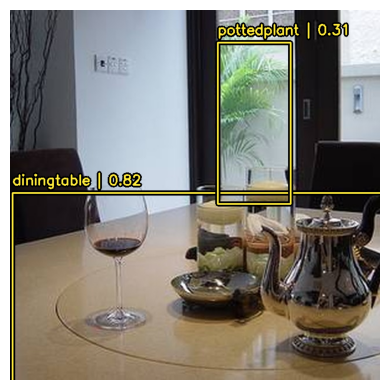

In [25]:
pred2 = run_one_image(image_urls[2])

    - Which objects were detected correctly
        the both pottedplant and diningtable
    - The confidence scores of the detections
        pottedplant — confidence 0.31
        diningtable — confidence 0.82
    - Any missed or incorrectly labeled objects
        no

Image downloaded to /var/folders/15/qj8415356nd_bbq1jnqh98_m0000gn/T/tmpwsygjg_6.jpg.


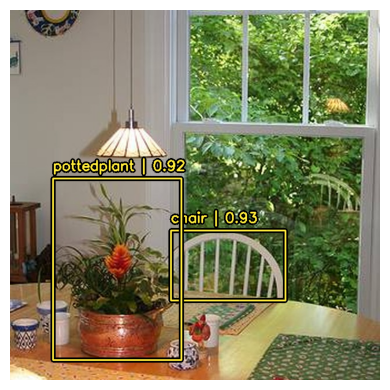

In [26]:
pred3 = run_one_image(image_urls[3])

    - Which objects were detected correctly
        the both pottedplant and chair
    - The confidence scores of the detections
        pottedplant — confidence 0.92
        chair — confidence 0.93
    - Any missed or incorrectly labeled objects
        missed diningtable

Image downloaded to /var/folders/15/qj8415356nd_bbq1jnqh98_m0000gn/T/tmpxn_erq0g.jpg.


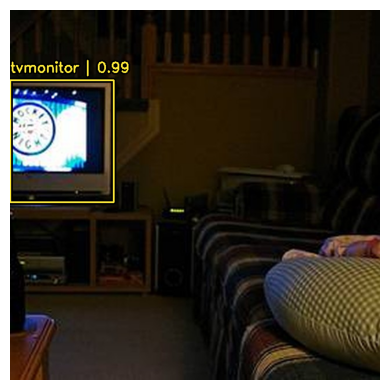

In [27]:
pred4 = run_one_image(image_urls[4])

    - Which objects were detected correctly
        only tvmonitor
    - The confidence scores of the detections
        tvmonitor — confidence 0.99
    - Any missed or incorrectly labeled objects
        missed sofa